<a href="https://colab.research.google.com/github/punit123-bit/workshop/blob/main/DG_IITG_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seeing the World: Basics of Convolutions & CNNs

Welcome to Deep Learning! We are moving beyond the limitations of MLPs to build networks that look at the world the way humans do: by scanning for patterns, shapes, and textures.

### 1. The Core Concept: The "Sliding Window"

Imagine you are looking for "Waldo" in a "Where's Waldo?" book. You don't stare at the entire page at once and hope your brain magically processes it. You scan. You focus on a small patch, check if it looks like Waldo, and then slide your eyes to the next patch.

This "scanning" process is exactly what a **Convolution** is.

**The Components:**

1. **The Input Image:** A matrix of pixel values (e.g., 5x5).

2. **The Kernel (or Filter):** A much smaller matrix (e.g., 3x3) containing learnable weights. This is our "scanner."

**The Operation:**

1. We place the 3x3 Kernel on top of the top-left corner of the Image.

2. We perform an **element-wise multiplication** between the Kernel values and the Image pixel values underneath them.

3. We **sum** these products up to get a single number.

4. We record this number in a new matrix called the **Feature Map**.

5. We slide the Kernel over one step and repeat until we've scanned the whole image.

**Why do we do this?**
Because the Kernel acts as a **feature detector**.

* If the Kernel represents a vertical line structure, the math will output a *high number* when it hovers over a vertical line in the image.

* If the Kernel hovers over a blank space, it outputs a *low number*.

### 2. Stride and Padding

There are two technical details that control how this window slides:

* **Stride:** How big of a step does the window take?

  * Stride = 1: Move 1 pixel at a time. High detail, large output.

  * Stride = 2: Jump 2 pixels. Reduces the size of the output feature map.

* **Padding:** When we scan the edges of the image, the window "falls off."

  * **Valid Padding:** We just stop scanning at the edge. The output gets smaller (a 5x5 image becomes 3x3).

  * **Same (Zero) Padding:** We add a border of zeros around the image so the output stays the same size (5x5 stays 5x5).

### 3. Pooling: The "Zoom Out"

After we detect features with convolutions, we often end up with a lot of data. We need to summarize.

**Pooling** layers (usually **Max Pooling**) reduce the spatial size of the representation. It simply looks at a 2x2 patch of the feature map and keeps only the **largest number**.

**Why Pool?**

1. **Reduces Computation:** Fewer parameters to calculate later.

2. **Translation Invariance:** If the "ear" of the cat moves 1 pixel to the right, Max Pooling will likely still catch the same high value. It makes the model robust to small movements.

### 4. The Full Architecture: Putting it Together

A typical CNN is a sandwich of layers:

1. **Input Image**

2. **Convolution Layer:** Detects simple features (edges, colors).

3. **ReLU Activation:** Adds non-linearity (removes negative values).

4. **Pooling Layer:** Shrinks the map.

5. **Convolution Layer 2:** Detects complex features (shapes, eyes, noses) by combining simple features.

6. **Pooling Layer 2:** Shrinks again.

7. **Flatten:** Turn the 2D maps into a 1D vector.

8. **Fully Connected Layer (MLP):** The classifier we learned before. It takes the features and decides "Cat" or "Dog."

In an MLP, the neuron learns a specific pixel value. In a CNN, the **Kernel** learns a pattern. Once a kernel learns to recognize a "curve," it can find that curve anywhere in the image. This is why CNNs are so powerful.

---
## Code Examples: PyTorch CNNs

Let's see this in action.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### Example 1: The Magic of Convolutions (Visualizing Filters)

We will manually apply a "Sobel Filter" to detect vertical edges. This proves that convolution is just feature detection.


--- Example 1: Manual Convolution (Edge Detection) ---


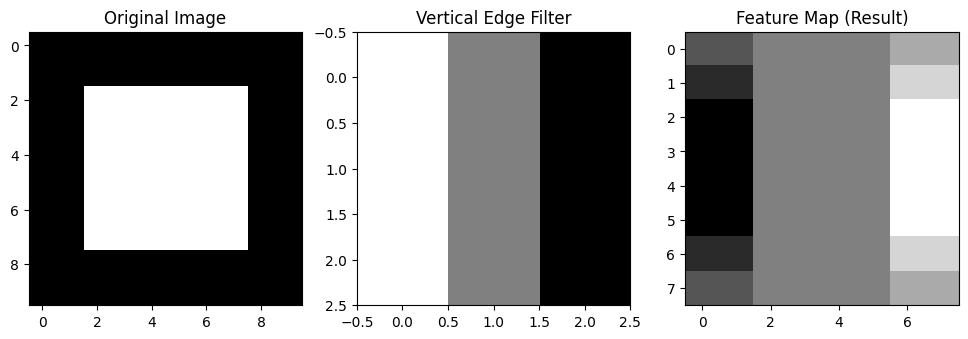

Look at the Feature Map! The vertical sides of the square light up.
The horizontal sides are invisible to this filter.


In [ ]:
print("\n--- Example 1: Manual Convolution (Edge Detection) ---")

def apply_manual_filter():
    # 1. Create a dummy image (grayscale)
    # A simple square: 0s (black) on the outside, 1s (white) on the inside
    image = np.zeros((10, 10))
    image[2:8, 2:8] = 1.0

    # Convert to PyTorch tensor: [Batch_Size, Channels, Height, Width]
    # We have 1 image, 1 channel (grayscale), 10x10 size
    input_tensor = torch.tensor(image, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

    # 2. Define a Vertical Edge Detection Kernel (Sobel-like)
    # Left column is positive, right column is negative.
    # This detects changes from bright to dark horizontally.
    kernel_data = np.array([
        [1.0, 0.0, -1.0],
        [1.0, 0.0, -1.0],
        [1.0, 0.0, -1.0]
    ])
    weights = torch.tensor(kernel_data, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

    # 3. Apply Convolution using functional API
    # We use valid padding (no zero padding)
    output = F.conv2d(input_tensor, weights, padding=0)

    # 4. Visualization
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # Original Image
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title("Original Image")

    # The Filter
    axes[1].imshow(kernel_data, cmap='gray')
    axes[1].set_title("Vertical Edge Filter")

    # The Result (Feature Map)
    # .detach() removes it from the computational graph for plotting
    axes[2].imshow(output[0, 0].detach().numpy(), cmap='gray')
    axes[2].set_title("Feature Map (Result)")

    plt.show()
    print("Look at the Feature Map! The vertical sides of the square light up.")
    print("The horizontal sides are invisible to this filter.")

apply_manual_filter()

### Example 2: Building a Real CNN for CIFAR-10

CIFAR-10 has 10 classes (airplane, automobile, bird, cat, etc.). We will build a CNN to classify them.

In [ ]:
print("\n--- Example 2: Training a CNN on CIFAR-10 ---")

# 1. Hyperparameters
batch_size = 64
learning_rate = 0.001
epochs = 3 # Keeping it short for demo

# 2. Data Preparation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print("Downloading CIFAR-10 dataset...")
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                           download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                          download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 3. Define the CNN Architecture
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # Convolutional Block 1
        # Input: 3 channels (RGB), Output: 32 channels (32 filters), Kernel: 3x3
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Reduces 32x32 -> 16x16

        # Convolutional Block 2
        # Input: 32 channels, Output: 64 channels, Kernel: 3x3
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        # Pool reduces 16x16 -> 8x8

        # Fully Connected Layers
        # Input features: 64 channels * 8 * 8 size = 4096
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10) # 10 Output classes

    def forward(self, x):
        # Block 1: Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv1(x)))
        # Block 2: Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv2(x)))
        # Flatten
        x = x.view(-1, 64 * 8 * 8)
        # FC Layers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)

# 4. Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 5. Training Loop
print("\nStarting Training...")
for epoch in range(epochs):
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f'Epoch [{epoch + 1}/{epochs}] Loss: {running_loss / len(train_loader):.4f}')

print("Training Finished.")

In [ ]:
# 6. Evaluation
print("\nEvaluating on Test Set...")
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy on test images: {100 * correct / total:.2f} %')

# 7. Visualize Predictions
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images[:4].to(device), labels[:4].to(device)

outputs = model(images)
_, predicted = torch.max(outputs, 1)

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.cpu().numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

print("\nSample Predictions:")
imshow(torchvision.utils.make_grid(images.cpu()))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))
print('Predicted:   ', ' '.join(f'{classes[predicted[j]]:5s}' for j in range(4)))